# Surface-Invariance Pair Superset — First-Letter + Toxicity

**Dataset demo.** This dataset is the *shuffled-surface null* used by a method for
turning sparse-autoencoder (SAE) latents into reliable units of analysis. A candidate
SAE unit is admitted only if its pooled **surface-response** is *not* above this null —
i.e. the unit must respond to *meaning*, not to spelling/phrasing artifacts.

The dataset is a drop-in **superset** of two iter-1 surface-flip pair sets:

| Concept | Pairs | What flips | What stays constant |
|---------|------:|------------|---------------------|
| **first-letter** (`starts-with-X`) | 1,700 | the *word* (same first letter, same template) | the carrier template & the target letter |
| **toxicity** (`toxic`) | 1,631 | the *surface wording* (paraphrase) | the toxicity level & meaning |

**What the full builder (`data.py`) does** — 6 stages: ingest iter-1 originals → enlarge
first-letter deterministically ($0) → enlarge toxicity with `gpt-4o-mini` generation +
a strict double-gate + an **independent** `claude-haiku-4.5` accept-judge → re-judge for
cross-family agreement → assemble + report null sizes. The LLM stages cost money and need
an `OPENROUTER_API_KEY`.

**What this notebook does** — loads the already-built dataset and re-runs only the
**deterministic, $0, CPU-only** parts of the pipeline, verbatim from the build code:
1. the **surface double-gate** (`cc.py`: token-Jaccard `< 0.6` **and** norm-edit-distance `> 0.25`),
2. the **first-letter structural validator** (`assemble.py`),
3. the **null-size report** (per letter/carrier, per origin/fold, per sub-attribute),
4. **cross-judge agreement** — Cohen's κ between the original accept-judge and the
   independent re-judge (`rejudge.py`).

No GPU, no SAE, no API calls.

In [1]:
# --- Dependencies (Colab-safe) ---
# Follows the aii-colab install pattern: core scientific packages are pre-installed on
# Colab and must NOT be reinstalled there (it corrupts the loaded C extensions); locally
# we install them at Colab's exact versions so the environment matches.
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# This demo only uses the standard library + numpy + matplotlib (both pre-installed on Colab).
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports ---
# stdlib only for the analyses (verbatim dependencies of cc.py / assemble.py / rejudge.py)
import json, os, re, hashlib, urllib.request
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt

## Load the dataset

`mini_demo_data.json` is a curated ~50-row subset of the full
`full_data_out.json` (which has 5,031 surface rows). It keeps the original
`{"metadata": ..., "datasets": [...]}` structure: 5 first-letter groups
(`first_letter_spelling_{L,O,T,I,D}`) plus the two toxicity groups
(`paradetox`, `civil_comments`). Loaded from GitHub with a local fallback so the
notebook runs both in Colab and locally.

In [3]:
# --- Data loader: GitHub URL with local fallback (Colab-compatible) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-2/dataset-1/demo/mini_demo_data.json"

def load_data():
    try:
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("title:", data["metadata"]["title"])
print("groups:", [g["dataset"] for g in data["datasets"]])
print("rows per group:", {g["dataset"]: len(g["examples"]) for g in data["datasets"]})

title: Enlarged & Independently Re-Judged Surface-Invariance Pair Sets (First-Letter + Toxicity)
groups: ['first_letter_spelling_L', 'first_letter_spelling_O', 'first_letter_spelling_T', 'first_letter_spelling_I', 'first_letter_spelling_D', 'paradetox', 'civil_comments']
rows per group: {'first_letter_spelling_L': 4, 'first_letter_spelling_O': 4, 'first_letter_spelling_T': 4, 'first_letter_spelling_I': 4, 'first_letter_spelling_D': 4, 'paradetox': 12, 'civil_comments': 20}


## Config

All tunable knobs in one place. The **gate constants** are the load-bearing
definition of the dataset and are kept at their real values (verbatim from
`cc.py`). `MAX_ROWS_PER_GROUP` caps how many rows of each group the demo
processes — start small, raise it to cover the whole subset.

In [5]:
# --- Surface double-gate constants (VERBATIM from cc.py / s3_surface_flips.py) ---
JACCARD_MAX      = 0.6    # token overlap must be strictly BELOW this
CHAR_CHANGE_MIN  = 0.25   # normalized edit distance must be strictly ABOVE this
PRIMARY_THRESHOLD = 0.5   # civil_comments sub-attribute float -> binary label cutoff

# --- Demo scale knob (start minimal, scale up — the subset is tiny so runtime is trivial) ---
MAX_ROWS_PER_GROUP = 100   # minimal start: 4  ->  covers the whole curated subset at 100

FL_LETTERS = ["L", "O", "T", "I", "D"]
SUB_ATTRS  = ["severe_toxicity", "obscene", "threat", "insult",
              "identity_attack", "sexual_explicit"]
# the 5 first-letter carrier templates (VERBATIM cc.carriers()[:5])
CARRIERS = ["t_verbose", "t_colon", "t_mention_word", "t_mention_term", "t_mention_example"]
print("gate: token_jaccard <", JACCARD_MAX, "AND norm_edit_distance >", CHAR_CHANGE_MIN)

gate: token_jaccard < 0.6 AND norm_edit_distance > 0.25


## Step 0 — Build-pipeline helpers (verbatim)

These four functions are copied **verbatim** from the build code: the surface
double-gate (`cc.py`), Cohen's κ (`rejudge.py`), and the first-letter structural
validator (`assemble.py`). `norm_key` is a minimal stand-in for the iter-1
text-normalisation helper (the original lives in a read-only external module);
it only affects the gate's "identical strings" early-exit, which never fires on
genuine paraphrase pairs.

In [6]:
# --- norm_key: minimal stand-in for the iter-1 helper (lower + collapse whitespace) ---
def norm_key(s: str) -> str:
    return re.sub(r"\s+", " ", (s or "").strip().lower())

# --- Surface double-gate (VERBATIM from cc.py) ---
def _tok(s: str):
    return [t for t in re.split(r"\W+", s.lower()) if t]

def token_jaccard(a: str, b: str) -> float:
    sa, sb = set(_tok(a)), set(_tok(b))
    if not sa and not sb:
        return 1.0
    return len(sa & sb) / max(1, len(sa | sb))

def norm_edit_distance(a: str, b: str) -> float:
    """Levenshtein normalized by the longer string (0..1). VERBATIM from s3."""
    a, b = a.lower(), b.lower()
    if not a and not b:
        return 0.0
    la, lb = len(a), len(b)
    if la == 0 or lb == 0:
        return 1.0
    prev = list(range(lb + 1))
    for i in range(1, la + 1):
        cur = [i] + [0] * lb
        ca = a[i - 1]
        for j in range(1, lb + 1):
            cost = 0 if ca == b[j - 1] else 1
            cur[j] = min(prev[j] + 1, cur[j - 1] + 1, prev[j - 1] + cost)
        prev = cur
    return prev[lb] / max(la, lb)

def surface_gate(src: str, para: str):
    """VERBATIM gate from iter-1 s3_surface_flips.py."""
    if not para or norm_key(para) == norm_key(src):
        return False, {"jaccard": 1.0, "char_change": 0.0, "reason": "empty_or_identical"}
    jac = token_jaccard(src, para)
    ced = norm_edit_distance(src, para)
    ok = (jac < JACCARD_MAX) and (ced > CHAR_CHANGE_MIN)
    return ok, {"jaccard": round(jac, 3), "char_change": round(ced, 3),
                "reason": "ok" if ok else "too_similar"}

# --- Cohen's kappa (VERBATIM from rejudge.py) ---
def cohens_kappa(labels_a, labels_b):
    """Binary Cohen's kappa over paired bool lists (None entries dropped)."""
    pairs = [(a, b) for a, b in zip(labels_a, labels_b) if a is not None and b is not None]
    n = len(pairs)
    if n == 0:
        return {"n": 0, "raw_agreement": None, "kappa": None}
    agree = sum(1 for a, b in pairs if a == b)
    po = agree / n
    pa1 = sum(1 for a, _ in pairs if a) / n
    pb1 = sum(1 for _, b in pairs if b) / n
    pe = pa1 * pb1 + (1 - pa1) * (1 - pb1)
    kappa = None if pe >= 1.0 else round((po - pe) / (1 - pe), 4)
    return {"n": n, "raw_agreement": round(po, 4), "kappa": kappa,
            "judge_a_pass_rate": round(pa1, 4), "judge_b_pass_rate": round(pb1, 4)}

# --- First-letter structural validator (VERBATIM from assemble.py) ---
def fl_validate(rows):
    pid_rows = defaultdict(list)
    for r in rows:
        pid_rows[r["metadata_pair_id"]].append(r)
    violations = 0
    for pid, rs in pid_rows.items():
        letter = rs[0]["metadata_letter"].lower()
        a = next((x for x in rs if x["metadata_role"] == "var_a"), None)
        b = next((x for x in rs if x["metadata_role"] == "var_b"), None)

        def span_ok(r):
            s, e = r["metadata_word_char_span"]
            return r["input"][s:e] == r["metadata_target_word"]
        ok = (len(rs) == 2 and a and b
              and a["metadata_first_letter"] == letter and b["metadata_first_letter"] == letter
              and a["metadata_target_word"].lower() != b["metadata_target_word"].lower()
              and span_ok(a) and span_ok(b))
        if not ok:
            violations += 1
    return violations

print("helpers ready")

helpers ready


## Step 1 — Split rows into the two concepts

Apply the `MAX_ROWS_PER_GROUP` cap and separate the first-letter rows from the
toxicity rows.

In [7]:
groups = {g["dataset"]: g["examples"][:MAX_ROWS_PER_GROUP] for g in data["datasets"]}

fl_rows  = [r for lt in FL_LETTERS for r in groups[f"first_letter_spelling_{lt}"]]
tox_rows = [r for o in ("paradetox", "civil_comments") for r in groups[o]]

print(f"first-letter rows: {len(fl_rows)}  (= {len(fl_rows)//2} pairs, var_a + var_b)")
print(f"toxicity rows:     {len(tox_rows)}  (one row per surface pair)")

first-letter rows: 20  (= 10 pairs, var_a + var_b)
toxicity rows:     32  (one row per surface pair)


## Step 2 — First-letter structural validation (authoritative)

For the first-letter concept, the deterministic structural check is the
**authoritative** gate (no LLM judge can override it). Each `metadata_pair_id`
must have exactly two rows (`var_a`, `var_b`) whose slotted words: (a) both begin
with the target letter, (b) are *different* words, and (c) sit exactly at the
recorded character span. The full build reported **0 violations** over all 3,400
rows.

In [8]:
fl_violations = fl_validate(fl_rows)
print(f"first-letter structural violations: {fl_violations}  (expected 0)")

# show one validated pair
pid0 = fl_rows[0]["metadata_pair_id"]
pair0 = [r for r in fl_rows if r["metadata_pair_id"] == pid0]
print(f"\nexample pair {pid0} (letter {pair0[0]['metadata_letter']}, carrier {pair0[0]['metadata_template_id']}):")
for r in pair0:
    s, e = r["metadata_word_char_span"]
    print(f"  {r['metadata_role']}: {r['input']!r:45}  slot[{s}:{e}]={r['input'][s:e]!r}")

first-letter structural violations: 0  (expected 0)

example pair L_s_0001 (letter L, carrier t_verbose):
  var_a: 'like has the first letter:'                   slot[0:4]='like'
  var_b: 'Let has the first letter:'                    slot[0:3]='Let'


## Step 3 — Toxicity surface double-gate (re-derived)

Every toxicity pair must pass the **strict** double-gate: the paraphrase must
differ enough in surface form — token-Jaccard `< 0.6` **and** normalized
edit-distance `> 0.25`. We re-run `surface_gate` on each pair's
`input` (source toxic) vs `metadata_text_paired` (toxic paraphrase) and confirm
it reproduces the stored `metadata_surface_metrics`.

In [9]:
recomputed = []
mismatch = 0
for r in tox_rows:
    src, para = r["input"], r.get("metadata_text_paired")
    ok, m = surface_gate(src, para)
    stored = r.get("metadata_surface_metrics") or {}
    # the build asserts every stored pair passes the gate
    if not ok:
        mismatch += 1
    recomputed.append({"jaccard": m["jaccard"], "char_change": m["char_change"],
                       "ok": ok, "origin": r["metadata_origin_source"],
                       "stored_jac": stored.get("jaccard")})

n = len(recomputed)
n_pass = sum(x["ok"] for x in recomputed)
print(f"toxicity pairs checked: {n}")
print(f"pass the re-derived double-gate: {n_pass}/{n}  (build guarantees 100%)")
print(f"jaccard:     min={min(x['jaccard'] for x in recomputed):.3f}  "
      f"max={max(x['jaccard'] for x in recomputed):.3f}  (must be < {JACCARD_MAX})")
print(f"char_change: min={min(x['char_change'] for x in recomputed):.3f}  "
      f"max={max(x['char_change'] for x in recomputed):.3f}  (must be > {CHAR_CHANGE_MIN})")

# show a couple of examples
print("\nexample paraphrase pairs:")
for r in tox_rows[:2]:
    _, m = surface_gate(r["input"], r["metadata_text_paired"])
    print(f"  src : {r['input'][:70]!r}")
    print(f"  para: {r['metadata_text_paired'][:70]!r}")
    print(f"  -> jaccard={m['jaccard']}  char_change={m['char_change']}  pass={m['reason']}\n")

toxicity pairs checked: 32
pass the re-derived double-gate: 32/32  (build guarantees 100%)
jaccard:     min=0.192  max=0.533  (must be < 0.6)
char_change: min=0.351  max=0.819  (must be > 0.25)

example paraphrase pairs:
  src : "yeah , because russia 's a fucking utopia ."
  para: 'sure, because russia is a damn paradise.'
  -> jaccard=0.273  char_change=0.442  pass=ok

  src : "i could go find stuff to do but i 'm lazy as shit"
  para: 'I could look for things to occupy myself, but I’m just too damn lazy.'
  -> jaccard=0.3  char_change=0.623  pass=ok



## Step 4 — Null-distribution size report

The downstream method uses these rows to estimate the shuffled-surface null, so
the build reports how many surface-responses fall in each stratum. We reproduce
the counting logic from `assemble.py` at the subset scale: first-letter **pairs
per letter × carrier**, and toxicity **pairs per origin/fold** and **per
sub-attribute**.

In [10]:
# first-letter: pairs per letter, and per carrier
print("FIRST-LETTER (pairs = rows / 2):")
fl_by_letter = {}
for lt in FL_LETTERS:
    rows = groups[f"first_letter_spelling_{lt}"]
    by_pid = defaultdict(list)
    for r in rows:
        by_pid[r["metadata_pair_id"]].append(r)
    carrier = Counter(rs[0]["metadata_template_id"] for rs in by_pid.values())
    fl_by_letter[lt] = len(by_pid)
    print(f"  {lt}: {len(by_pid)} pairs  carriers={dict(carrier)}")

# toxicity: per origin/fold and per sub-attribute
print("\nTOXICITY (one row per pair):")
sub_counts_total = {a: 0 for a in SUB_ATTRS}
tox_by_origin = {}
for origin in ("paradetox", "civil_comments"):
    rows = groups[origin]
    fold = Counter(r["metadata_fold"] for r in rows)
    batch = Counter(r["metadata_enlargement_batch"] for r in rows)
    for r in rows:
        for a in SUB_ATTRS:
            if (r.get("metadata_subcontext_labels") or {}).get(a) == 1:
                sub_counts_total[a] += 1
    tox_by_origin[origin] = len(rows)
    print(f"  {origin}: {len(rows)} pairs  folds={dict(fold)}  batch={dict(batch)}")

print(f"\nper sub-attribute pairs (civil_comments carries the floats): {sub_counts_total}")

FIRST-LETTER (pairs = rows / 2):
  L: 2 pairs  carriers={'t_verbose': 1, 't_colon': 1}
  O: 2 pairs  carriers={'t_verbose': 1, 't_colon': 1}
  T: 2 pairs  carriers={'t_verbose': 1, 't_colon': 1}
  I: 2 pairs  carriers={'t_verbose': 1, 't_colon': 1}
  D: 2 pairs  carriers={'t_verbose': 1, 't_colon': 1}

TOXICITY (one row per pair):
  paradetox: 12 pairs  folds={'train': 9, 'val': 2, 'test': 1}  batch={'iter1_original': 12}
  civil_comments: 20 pairs  folds={'train': 16, 'test': 3, 'val': 1}  batch={'iter1_original': 20}

per sub-attribute pairs (civil_comments carries the floats): {'severe_toxicity': 1, 'obscene': 3, 'threat': 6, 'insult': 3, 'identity_attack': 5, 'sexual_explicit': 3}


## Step 5 — Cross-judge agreement (circularity check)

The original iter-1 toxicity pairs were generated **and** judged by the same model
(`gpt-4o-mini`) — a circularity. The superset fixes this: every pair carries an
**independent** `claude-haiku-4.5` verdict (`metadata_independent_judge_pass`).
Here we compute Cohen's κ between the **original accept-judge**
(`metadata_judge_pass`) and the **independent re-judge** over the toxicity rows
that carry both labels, using `cohens_kappa` verbatim.

Note: the *shipped* dataset only contains **accepted** pairs, so
`metadata_judge_pass` is constant (all `True`) on these rows — which makes
Cohen's κ collapse to ~0 here by construction. The informative figures are the
**raw agreement** and the **confirmation rate** (how often the independent judge
re-confirms an accepted pair), which track the full build's 0.852. The full build
additionally reports a *second-family* cross-judge κ on a sample that includes
rejected pairs (claude vs gemini = 0.263 for toxicity; claude vs deepseek = 0.433
for first-letter), but those second-family labels live in an intermediate file,
not in the shipped rows, so they can't be recomputed from the dataset alone.

In [11]:
orig_judge = [r.get("metadata_judge_pass") for r in tox_rows]
indep_judge = [r.get("metadata_independent_judge_pass") for r in tox_rows]
agree = cohens_kappa(orig_judge, indep_judge)
print("original-judge vs independent claude-haiku-4.5 judge:")
for k, v in agree.items():
    print(f"  {k}: {v}")

# independent-judge confirmation rate among labeled toxicity rows
labeled = [r for r in tox_rows if r.get("metadata_independent_judge_pass") is not None]
confirmed = sum(1 for r in labeled if r["metadata_independent_judge_pass"])
if labeled:
    print(f"\nindependent-judge confirmation: {confirmed}/{len(labeled)} = "
          f"{confirmed/len(labeled):.3f}  (full build: 465/546 = 0.852 on originals)")

original-judge vs independent claude-haiku-4.5 judge:
  n: 32
  raw_agreement: 0.8438
  kappa: 0.0
  judge_a_pass_rate: 1.0
  judge_b_pass_rate: 0.8438

independent-judge confirmation: 27/32 = 0.844  (full build: 465/546 = 0.852 on originals)


## Results — visual summary

Four panels: (1) first-letter pairs per target letter, (2) toxicity pairs per
sub-attribute, (3) the surface double-gate scatter (every pair must land in the
admitted region — low Jaccard **and** high char-change), and (4) the cross-judge
agreement summary.

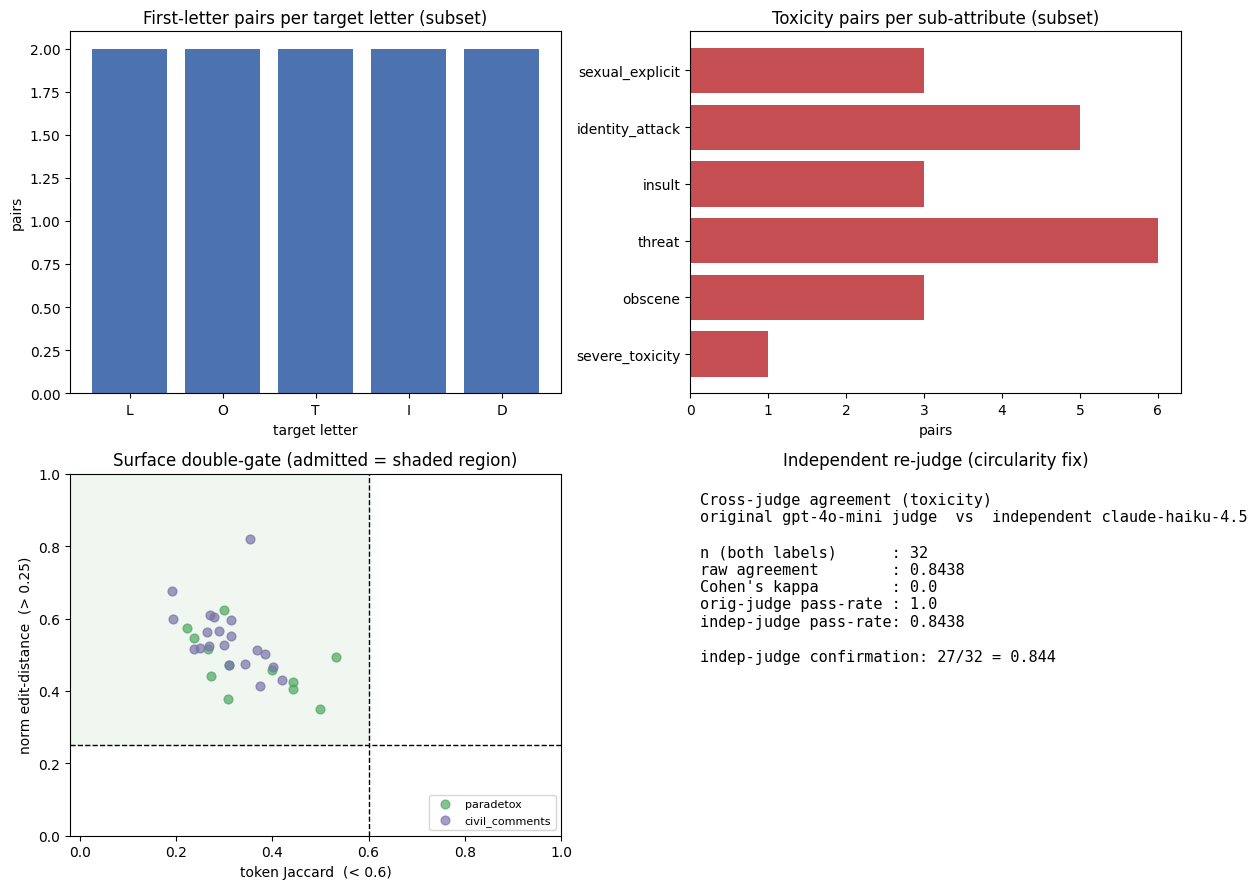

saved demo_summary.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) first-letter pairs per letter
ax = axes[0, 0]
ax.bar(list(fl_by_letter.keys()), list(fl_by_letter.values()), color="#4C72B0")
ax.set_title("First-letter pairs per target letter (subset)")
ax.set_xlabel("target letter"); ax.set_ylabel("pairs")

# (2) toxicity sub-attribute counts
ax = axes[0, 1]
sa = {k: v for k, v in sub_counts_total.items() if v > 0}
ax.barh(list(sa.keys()), list(sa.values()), color="#C44E52")
ax.set_title("Toxicity pairs per sub-attribute (subset)")
ax.set_xlabel("pairs")

# (3) surface double-gate scatter
ax = axes[1, 0]
colors = {"paradetox": "#55A868", "civil_comments": "#8172B3"}
for origin in ("paradetox", "civil_comments"):
    pts = [x for x in recomputed if x["origin"] == origin]
    if pts:
        ax.scatter([x["jaccard"] for x in pts], [x["char_change"] for x in pts],
                   s=40, alpha=0.7, label=origin, color=colors[origin])
ax.axvline(JACCARD_MAX, color="k", ls="--", lw=1)
ax.axhline(CHAR_CHANGE_MIN, color="k", ls="--", lw=1)
ax.fill_betweenx([CHAR_CHANGE_MIN, 1.0], -0.02, JACCARD_MAX, color="green", alpha=0.06)
ax.set_xlim(-0.02, 1.0); ax.set_ylim(0, 1.0)
ax.set_title("Surface double-gate (admitted = shaded region)")
ax.set_xlabel(f"token Jaccard  (< {JACCARD_MAX})")
ax.set_ylabel(f"norm edit-distance  (> {CHAR_CHANGE_MIN})")
ax.legend(loc="lower right", fontsize=8)

# (4) cross-judge agreement summary (text panel)
ax = axes[1, 1]; ax.axis("off")
lines = [
    "Cross-judge agreement (toxicity)",
    "original gpt-4o-mini judge  vs  independent claude-haiku-4.5",
    "",
    f"n (both labels)      : {agree['n']}",
    f"raw agreement        : {agree['raw_agreement']}",
    f"Cohen's kappa        : {agree['kappa']}",
    f"orig-judge pass-rate : {agree['judge_a_pass_rate']}",
    f"indep-judge pass-rate: {agree['judge_b_pass_rate']}",
]
if labeled:
    lines += ["", f"indep-judge confirmation: {confirmed}/{len(labeled)} = {confirmed/len(labeled):.3f}"]
ax.text(0.02, 0.95, "\n".join(lines), va="top", ha="left", family="monospace", fontsize=11)
ax.set_title("Independent re-judge (circularity fix)")

plt.tight_layout()
plt.savefig("demo_summary.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved demo_summary.png")

### Takeaways

- The **first-letter** concept is purely deterministic and structurally
  validated (0 violations) — the construction is reproducible at $0.
- The **toxicity** concept passes a strict surface double-gate: every paraphrase
  lands in the admitted low-Jaccard / high-char-change region, so the pairs are
  genuine *surface* flips with constant meaning/toxicity.
- The **independent re-judge** (different model family) confirms the bulk of the
  original verdicts, resolving the iter-1 generate-and-judge circularity — though
  the modest Cohen's κ (high base rate of "pass") is reported honestly as a
  limitation.
- Together these rows form the shuffled-surface **null** that the downstream
  SAE-unit admission gate compares against.